In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_curve, auc

plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True

In [25]:
base_dir_run1 = "/home/paul/Msci/dm_sets/run1_samples/"
base_dir_run3 = "/home/paul/Msci/dm_sets/run3_samples/"
signal_dir_run1 = "/home/paul/Msci/dm_sets/run1_signal/"
signal_dir_run3 = "/home/paul/Msci/dm_sets/run3_signal/"
plot_dir = "/home/paul/Msci/plots/sparsity"

run = "combined"  # "run1", "run3", or "combined"

def load_run(run_tag, base_dir, signal_dir):
    df_signal = pd.read_csv(signal_dir + f"{run_tag}_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores.csv").drop_duplicates()
    df_signal['label'] = 1
    
    df_nu = pd.read_csv(base_dir + f"{run_tag}_nu_overlay_merged_with_weights.csv").drop_duplicates()
    df_nu['label'] = 0
    
    df_dirt = pd.read_csv(base_dir + f"{run_tag}_dirt_merged_with_weights.csv").drop_duplicates()
    df_dirt['label'] = 0
    
    if run_tag == "run1":
        df_offbeam = pd.read_csv(base_dir + "run1_offbeam_larcv_cropped_full_set_scores.csv").drop_duplicates()
    else:
        df_offbeam = pd.read_csv(base_dir + "run3_offbeam_larcv_cropped_scores.csv").drop_duplicates()
    df_offbeam['label'] = 0
    
    return pd.concat([df_signal, df_nu, df_dirt, df_offbeam], ignore_index=True)

if run == "combined":
    df_run1 = load_run("run1", base_dir_run1, signal_dir_run1)
    df_run3 = load_run("run3", base_dir_run3, signal_dir_run3)
    df_all = pd.concat([df_run1, df_run3], ignore_index=True)
    signal_dir = signal_dir_run1
elif run == "run1":
    df_all = load_run("run1", base_dir_run1, signal_dir_run1)
    signal_dir = signal_dir_run1
else:
    df_all = load_run("run3", base_dir_run3, signal_dir_run3)
    signal_dir = signal_dir_run3

df_all = df_all[df_all['signal_score'] >= 0].copy()

print(f"Run: {run}")
print(f"Total events: {len(df_all)}")
print(f"Signal: {(df_all['label']==1).sum()}, Background: {(df_all['label']==0).sum()}")
print(f"\nn_pixels range: {df_all['n_pixels'].min():.0f} - {df_all['n_pixels'].max():.0f}")

Run: combined
Total events: 66632
Signal: 16303, Background: 50329

n_pixels range: 0 - 53510


In [26]:
total_pixels = 512 * 512
df_all['occupancy'] = df_all['n_pixels'] / total_pixels

print(f"Occupancy stats:")
print(f"  Mean:   {df_all['occupancy'].mean():.4f} ({df_all['occupancy'].mean()*100:.2f}%)")
print(f"  Median: {df_all['occupancy'].median():.4f} ({df_all['occupancy'].median()*100:.2f}%)")
print(f"  Max:    {df_all['occupancy'].max():.4f} ({df_all['occupancy'].max()*100:.2f}%)")

print(f"\nSignal occupancy:  {df_all[df_all['label']==1]['occupancy'].mean():.4f}")
print(f"Background occupancy: {df_all[df_all['label']==0]['occupancy'].mean():.4f}")

Occupancy stats:
  Mean:   0.0069 (0.69%)
  Median: 0.0060 (0.60%)
  Max:    0.2041 (20.41%)

Signal occupancy:  0.0081
Background occupancy: 0.0065


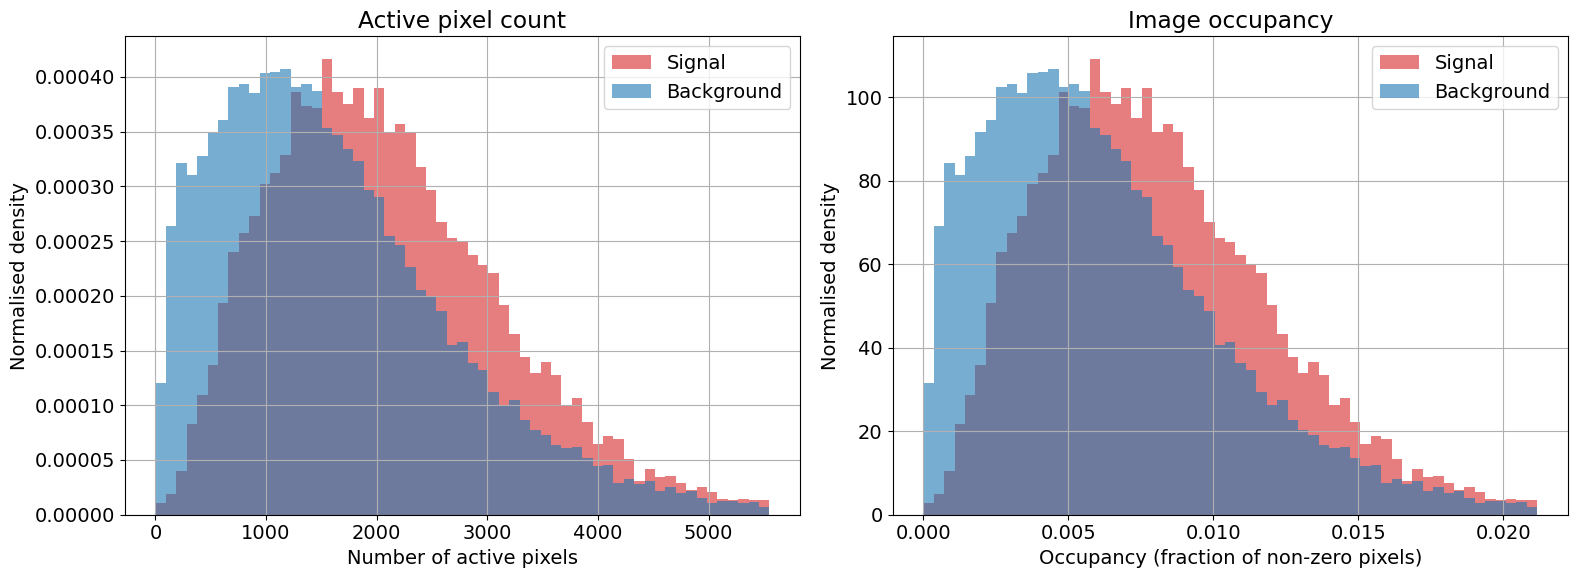

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: n_pixels
ax = axes[0]
bins_px = np.linspace(0, df_all['n_pixels'].quantile(0.99), 60)
ax.hist(df_all[df_all['label']==1]['n_pixels'], bins=bins_px, alpha=0.6, 
        density=True, label='Signal', color='tab:red')
ax.hist(df_all[df_all['label']==0]['n_pixels'], bins=bins_px, alpha=0.6, 
        density=True, label='Background', color='tab:blue')
ax.set_xlabel('Number of active pixels')
ax.set_ylabel('Normalised density')
ax.set_title('Active pixel count')
ax.legend()

# Right: occupancy
ax = axes[1]
bins_occ = np.linspace(0, df_all['occupancy'].quantile(0.99), 60)
ax.hist(df_all[df_all['label']==1]['occupancy'], bins=bins_occ, alpha=0.6, 
        density=True, label='Signal', color='tab:red')
ax.hist(df_all[df_all['label']==0]['occupancy'], bins=bins_occ, alpha=0.6, 
        density=True, label='Background', color='tab:blue')
ax.set_xlabel('Occupancy (fraction of non-zero pixels)')
ax.set_ylabel('Normalised density')
ax.set_title('Image occupancy')
ax.legend()

plt.tight_layout()
#plt.savefig(f"{plot_dir}/occupancy_distributions.png", bbox_inches='tight')
plt.show()

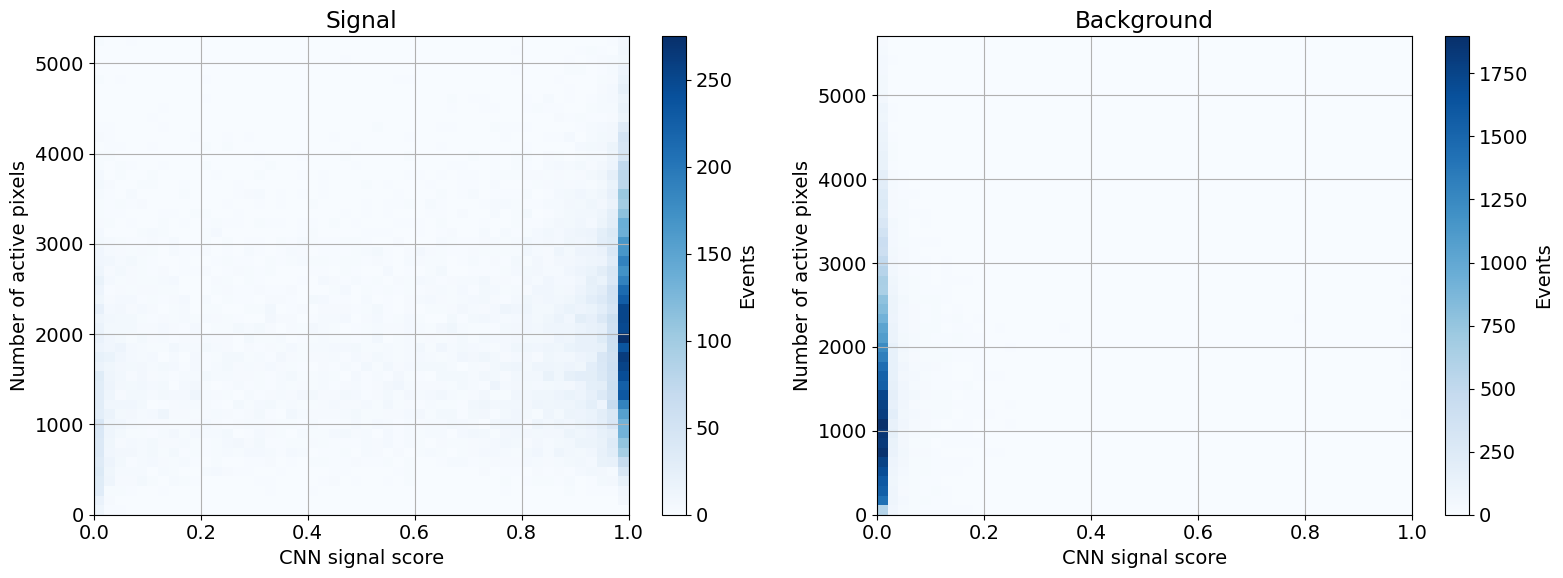

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sig = df_all[df_all['label'] == 1]
bkg = df_all[df_all['label'] == 0]

for ax, data, title in zip(axes, [sig, bkg], ['Signal', 'Background']):
    h = ax.hist2d(data['signal_score'], data['n_pixels'], 
                  bins=[50, 50], cmap='Blues',
                  range=[[0, 1], [0, data['n_pixels'].quantile(0.99)]])
    plt.colorbar(h[3], ax=ax, label='Events')
    ax.set_xlabel('CNN signal score')
    ax.set_ylabel('Number of active pixels')
    ax.set_title(title)

plt.tight_layout()
#plt.savefig(f'{plot_dir}/score_vs_npixels_2d.png', bbox_inches='tight')
plt.show()

In [29]:
# Signal events only
rho_sig, p_sig = stats.spearmanr(sig['n_pixels'], sig['signal_score'])
print(f"Signal:     Spearman rho = {rho_sig:.3f}, p = {p_sig:.2e}")

# Background events only  
rho_bkg, p_bkg = stats.spearmanr(bkg['n_pixels'], bkg['signal_score'])
print(f"Background: Spearman rho = {rho_bkg:.3f}, p = {p_bkg:.2e}")

# Correct vs incorrect classification (at 0.5 cut)
df_all['correct'] = ((df_all['signal_score'] >= 0.5) == (df_all['label'] == 1)).astype(int)
rho_corr, p_corr = stats.pointbiserialr(df_all['correct'], df_all['n_pixels'])
print(f"\nCorrect classification vs n_pixels: r_pb = {rho_corr:.3f}, p = {p_corr:.2e}")

Signal:     Spearman rho = 0.172, p = 1.37e-108
Background: Spearman rho = 0.188, p = 0.00e+00

Correct classification vs n_pixels: r_pb = -0.033, p = 8.87e-18


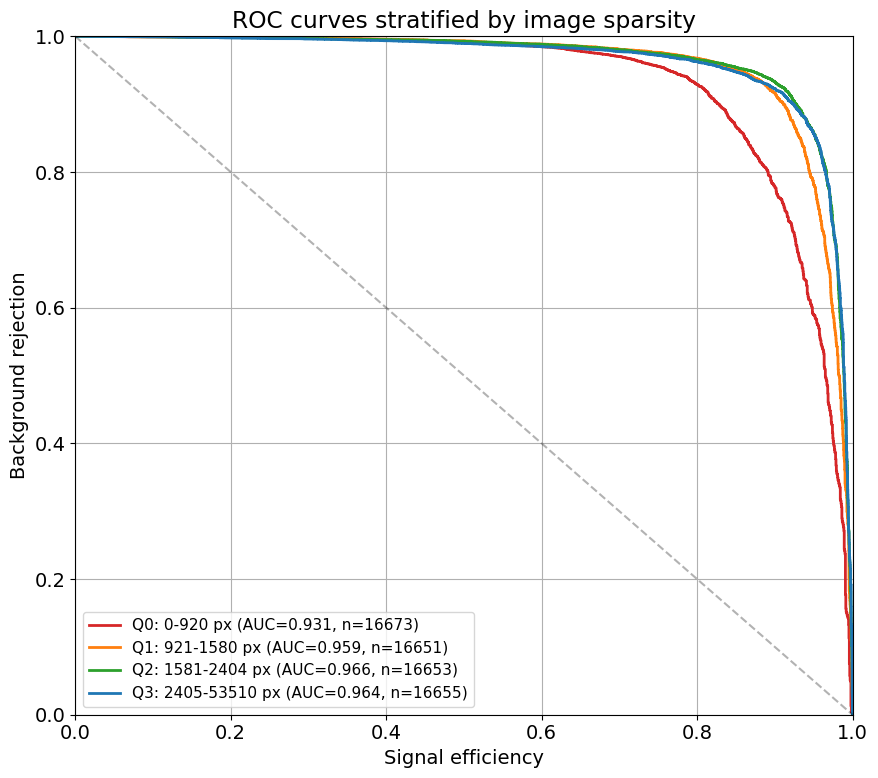

In [30]:
# Define sparsity quartiles based on n_pixels
df_all['sparsity_quartile'] = pd.qcut(df_all['n_pixels'], q=4, labels=False)

# Get the actual bin edges for labelling
quartile_edges = df_all.groupby('sparsity_quartile')['n_pixels'].agg(['min', 'max'])

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']  # red to blue = sparse to dense

for q in range(4):
    subset = df_all[df_all['sparsity_quartile'] == q]
    
    # Need both signal and background in each quartile
    n_sig = (subset['label'] == 1).sum()
    n_bkg = (subset['label'] == 0).sum()
    
    if n_sig < 10 or n_bkg < 10:
        print(f"Q{q}: too few events (sig={n_sig}, bkg={n_bkg}), skipping")
        continue
    
    fpr, tpr, _ = roc_curve(subset['label'], subset['signal_score'])
    roc_auc = auc(fpr, tpr)
    
    lo, hi = quartile_edges.loc[q, 'min'], quartile_edges.loc[q, 'max']
    ax.plot(tpr, 1-fpr, color=colors[q], lw=2,
            label=f'Q{q}: {lo:.0f}-{hi:.0f} px (AUC={roc_auc:.3f}, n={len(subset)})')

ax.plot([0, 1], [1, 0], 'k--', alpha=0.3)
ax.set_xlabel('Signal efficiency')
ax.set_ylabel('Background rejection')
ax.set_title('ROC curves stratified by image sparsity')
ax.legend(loc='lower left', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
#plt.savefig(f'{plot_dir}/roc_by_sparsity.png', bbox_inches='tight')
plt.show()

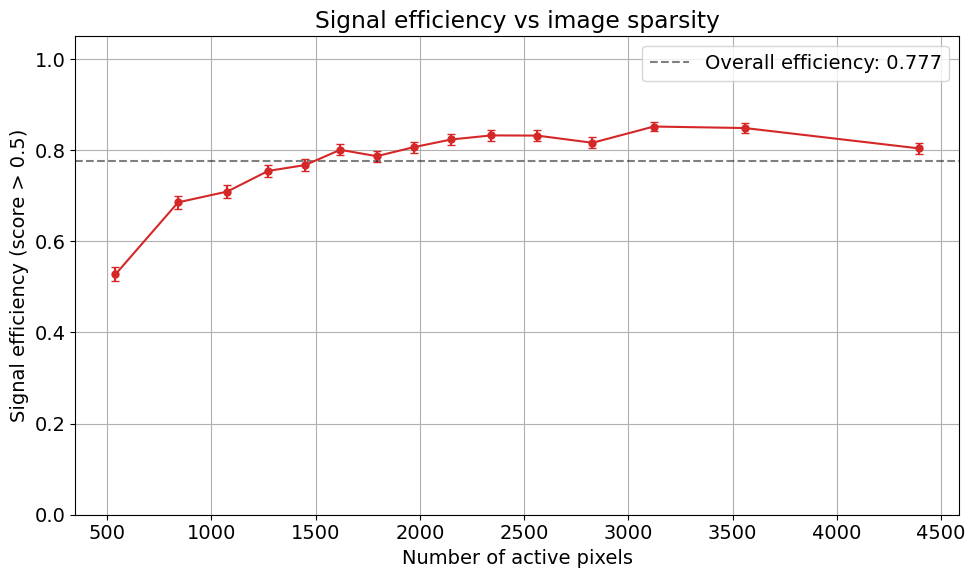

In [31]:
cut = 0.5

# Bin signal events by n_pixels
sig_only = df_all[df_all['label'] == 1].copy()
n_bins = 15
sig_only['px_bin'] = pd.qcut(sig_only['n_pixels'], q=n_bins, duplicates='drop')

eff_data = []
for name, group in sig_only.groupby('px_bin', observed=True):
    n_total = len(group)
    n_pass = (group['signal_score'] >= cut).sum()
    eff = n_pass / n_total if n_total > 0 else 0
    # Binomial error
    err = np.sqrt(eff * (1 - eff) / n_total) if n_total > 0 else 0
    mid = group['n_pixels'].median()
    eff_data.append({'mid': mid, 'eff': eff, 'err': err, 'n': n_total})

eff_df = pd.DataFrame(eff_data)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(eff_df['mid'], eff_df['eff'], yerr=eff_df['err'], 
            fmt='o-', color='tab:red', capsize=3, markersize=5)
ax.set_xlabel('Number of active pixels')
ax.set_ylabel(f'Signal efficiency (score > {cut})')
ax.set_title('Signal efficiency vs image sparsity')
ax.set_ylim([0, 1.05])
ax.axhline(y=sig_only['signal_score'].ge(cut).mean(), color='k', ls='--', 
           alpha=0.5, label=f'Overall efficiency: {sig_only["signal_score"].ge(cut).mean():.3f}')
ax.legend()

plt.tight_layout()
#plt.savefig(f'{plot_dir}/efficiency_vs_npixels.png', bbox_inches='tight')
plt.show()

Signal events:
  Correctly classified: 12660 events, median n_pixels = 2054
  Misclassified:       3643 events, median n_pixels = 1624
  KS test: D = 0.170, p = 5.09e-72
  Significant difference!


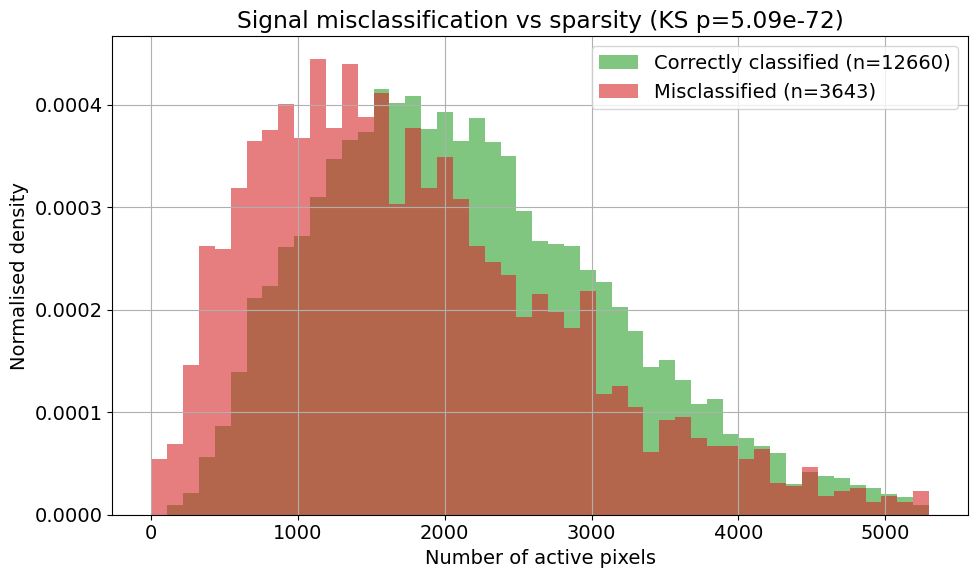

In [32]:
# For signal events: correctly classified (score >= 0.5) vs misclassified (score < 0.5)
sig_correct = sig_only[sig_only['signal_score'] >= cut]['n_pixels']
sig_misclass = sig_only[sig_only['signal_score'] < cut]['n_pixels']

ks_stat, ks_p = stats.ks_2samp(sig_correct, sig_misclass)
print(f"Signal events:")
print(f"  Correctly classified: {len(sig_correct)} events, median n_pixels = {sig_correct.median():.0f}")
print(f"  Misclassified:       {len(sig_misclass)} events, median n_pixels = {sig_misclass.median():.0f}")
print(f"  KS test: D = {ks_stat:.3f}, p = {ks_p:.2e}")
print(f"  {'Significant difference!' if ks_p < 0.05 else 'No significant difference.'}")

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, sig_only['n_pixels'].quantile(0.99), 50)
ax.hist(sig_correct, bins=bins, alpha=0.6, density=True, 
        label=f'Correctly classified (n={len(sig_correct)})', color='tab:green')
ax.hist(sig_misclass, bins=bins, alpha=0.6, density=True, 
        label=f'Misclassified (n={len(sig_misclass)})', color='tab:red')
ax.set_xlabel('Number of active pixels')
ax.set_ylabel('Normalised density')
ax.set_title(f'Signal misclassification vs sparsity (KS p={ks_p:.2e})')
ax.legend()

plt.tight_layout()
#plt.savefig(f'{plot_dir}/misclassification_sparsity.png', bbox_inches='tight')
plt.show()

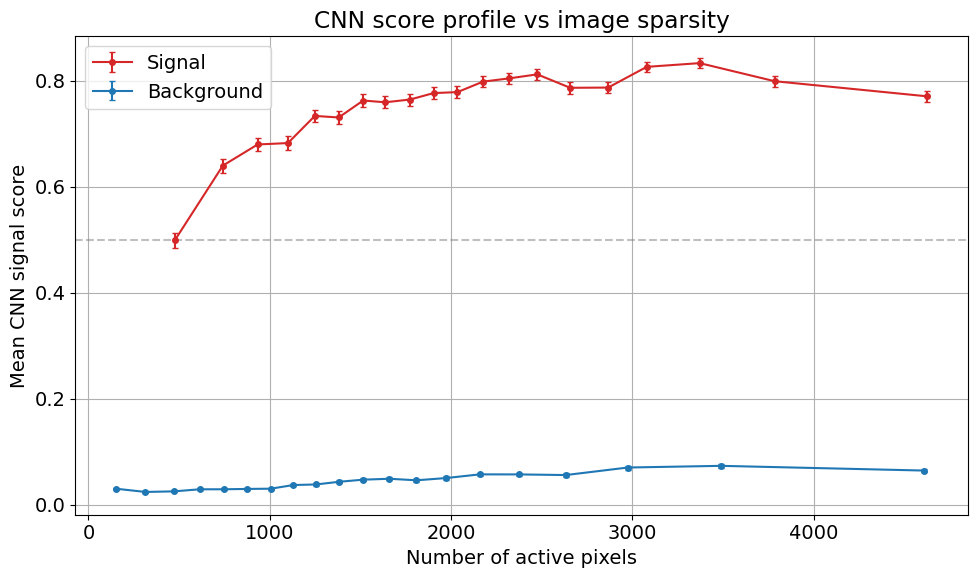

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

for data, label, color in [(sig, 'Signal', 'tab:red'), (bkg, 'Background', 'tab:blue')]:
    binned = pd.qcut(data['n_pixels'], q=20, duplicates='drop')
    grouped = data.groupby(binned, observed=True)['signal_score']
    means = grouped.mean()
    sems = grouped.sem()
    mids = data.groupby(binned, observed=True)['n_pixels'].median()
    
    ax.errorbar(mids, means, yerr=sems, fmt='o-', label=label, 
                color=color, capsize=2, markersize=4)

ax.set_xlabel('Number of active pixels')
ax.set_ylabel('Mean CNN signal score')
ax.set_title('CNN score profile vs image sparsity')
ax.legend()
ax.axhline(y=0.5, color='grey', ls='--', alpha=0.5)

plt.tight_layout()
#plt.savefig(f'{plot_dir}/score_profile_vs_npixels.png', bbox_inches='tight')
plt.show()

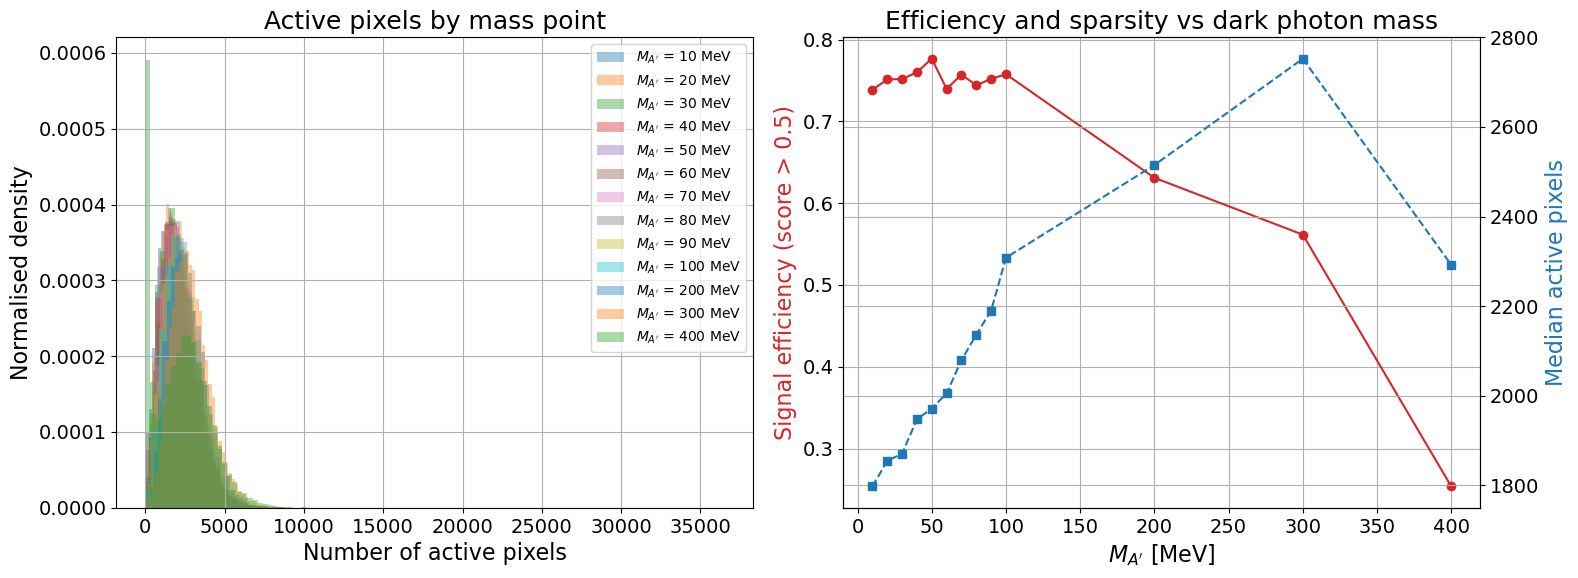


Run: combined
Mass 10 MeV: eff=0.739, median_px=1797
Mass 20 MeV: eff=0.751, median_px=1854
Mass 30 MeV: eff=0.752, median_px=1870
Mass 40 MeV: eff=0.760, median_px=1947
Mass 50 MeV: eff=0.777, median_px=1971
Mass 60 MeV: eff=0.740, median_px=2005
Mass 70 MeV: eff=0.757, median_px=2079
Mass 80 MeV: eff=0.744, median_px=2136
Mass 90 MeV: eff=0.752, median_px=2190
Mass 100 MeV: eff=0.758, median_px=2308
Mass 200 MeV: eff=0.631, median_px=2515
Mass 300 MeV: eff=0.561, median_px=2752
Mass 400 MeV: eff=0.254, median_px=2292


In [35]:
mass_points = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.20, 0.30, 0.40]

def get_mass_filename(run_tag, mass):
    if mass >= 0.1:
        return f"{run_tag}_dt_ratio_0.6_ma_{mass}_eta_larcv_cropped_scores.csv"
    else:
        return f"{run_tag}_dt_ratio_0.6_ma_{mass}_pi0_larcv_cropped_scores.csv"

def load_mass_files(run_tag, sig_dir):
    frames = {}
    for mass in mass_points:
        path = sig_dir + get_mass_filename(run_tag, mass)
        df = pd.read_csv(path)
        df = df[df['signal_score'] >= 0]
        frames[mass] = df
    return frames

if run == "combined":
    frames_run1 = load_mass_files("run1", signal_dir_run1)
    frames_run3 = load_mass_files("run3", signal_dir_run3)
    mass_frames = {mass: pd.concat([frames_run1[mass], frames_run3[mass]], ignore_index=True) for mass in mass_points}
elif run == "run1":
    mass_frames = load_mass_files("run1", signal_dir_run1)
else:
    mass_frames = load_mass_files("run3", signal_dir_run3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mass_stats = []
for mass in mass_points:
    df_m = mass_frames[mass]
    
    mass_stats.append({
        'mass': mass,
        'mean_npix': df_m['n_pixels'].mean(),
        'median_npix': df_m['n_pixels'].median(),
        'efficiency': (df_m['signal_score'] >= 0.5).mean(),
        'mean_score': df_m['signal_score'].mean()
    })
    
    axes[0].hist(df_m['n_pixels'], bins=50, alpha=0.4, density=True,
                 label=f"$M_{{A'}}$ = {mass*1000:.0f} MeV")

axes[0].set_xlabel('Number of active pixels', fontsize=16)
axes[0].set_ylabel('Normalised density', fontsize=16)
axes[0].set_title('Active pixels by mass point', fontsize=18)
axes[0].legend(fontsize=10)

ms = pd.DataFrame(mass_stats)
ax2 = axes[1]
ax2.plot(ms['mass']*1000, ms['efficiency'], 'o-', color='tab:red', label='Efficiency')
ax2.set_xlabel("$M_{A'}$ [MeV]", fontsize=16)
ax2.set_ylabel('Signal efficiency (score > 0.5)', color='tab:red', fontsize=16)
ax2_twin = ax2.twinx()
ax2_twin.plot(ms['mass']*1000, ms['median_npix'], 's--', color='tab:blue', label='Median pixels')
ax2_twin.set_ylabel('Median active pixels', color='tab:blue', fontsize=16)
ax2.set_title('Efficiency and sparsity vs dark photon mass', fontsize=18)

plt.tight_layout()
plt.savefig(f'{plot_dir}/mass_sparsity_efficiency_{run}.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nRun: {run}")
for _, row in ms.iterrows():
    print(f"Mass {row['mass']*1000:.0f} MeV: eff={row['efficiency']:.3f}, median_px={row['median_npix']:.0f}")

In [ ]:
print("=" * 70)
print("SPARSITY ANALYSIS SUMMARY")
print("=" * 70)
print(f"")
print(f"Image size: 512 x 512 = {512*512} pixels")
print(f"")
print(f"{'Sample':<15} {'N events':>10} {'Mean px':>10} {'Median px':>10} {'Occupancy':>10}")
print("-" * 55)
for name, data in [('Signal', sig), ('Background', bkg)]:
    print(f"{name:<15} {len(data):>10} {data['n_pixels'].mean():>10.0f} "
          f"{data['n_pixels'].median():>10.0f} {data['occupancy'].mean()*100:>9.2f}%")
print(f"")
print(f"Spearman correlation (n_pixels vs signal_score):")
print(f"  Signal:     rho = {rho_sig:.3f} (p = {p_sig:.2e})")
print(f"  Background: rho = {rho_bkg:.3f} (p = {p_bkg:.2e})")
print(f"")
print(f"Misclassification KS test (signal):")
print(f"  D = {ks_stat:.3f}, p = {ks_p:.2e}")
print(f"  Median n_pixels — correct: {sig_correct.median():.0f}, misclassified: {sig_misclass.median():.0f}")